In [1]:
!pip install keract

In [2]:
from tensorflow import lite
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

In [3]:
!kaggle datasets download -d sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
!unzip -q diabetic-retinopathy-224x224-gaussian-filtered.zip -d /content/dr_data

Dataset URL: https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
License(s): CC0-1.0
diabetic-retinopathy-224x224-gaussian-filtered.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/dr_data/gaussian_filtered_images/gaussian_filtered_images/Mild/0024cdab0c1e.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [16]:
import os

print(os.path.exists('/content/dr_data'))
print(os.listdir('/content/dr_data'))
img_path = '/content/dr_data/gaussian_filtered_images/gaussian_filtered_images'
print(len(os.listdir(img_path)))

True
['train.csv', 'gaussian_filtered_images']
6


In [17]:
import os

img_path = '/content/dr_data/gaussian_filtered_images/gaussian_filtered_images'

for folder in os.listdir(img_path):
    folder_path = os.path.join(img_path, folder)

    if os.path.isdir(folder_path):  # skip files like export.pkl
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")

Mild: 370 images
Moderate: 999 images
Severe: 193 images
Proliferate_DR: 295 images
No_DR: 1805 images


In [18]:
import pandas as pd

# Load the CSV from Google Colab path
df = pd.read_csv('/content/dr_data/train.csv')

# Mapping for binary classification
diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

# Mapping for 5-class classification
diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR'
}

# Add new columns
df['binary_type'] = df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)

# View first few rows
print(df.head())

        id_code  diagnosis binary_type            type
0  000c1434d8d7          2          DR        Moderate
1  001639a390f0          4          DR  Proliferate_DR
2  0024cdab0c1e          1          DR            Mild
3  002c21358ce6          0       No_DR           No_DR
4  005b95c28852          0       No_DR           No_DR


In [19]:
# Split into stratified train, val, and test sets
train_intermediate, val = train_test_split(df, test_size = 0.15, stratify = df['type'])
train, test = train_test_split(train_intermediate, test_size = 0.15 / (1 - 0.15), stratify = train_intermediate['type'])

print(train['type'].value_counts(), '\n')
print(test['type'].value_counts(), '\n')
print(val['type'].value_counts(), '\n')

type
No_DR             1263
Moderate           699
Mild               258
Proliferate_DR     207
Severe             135
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 



In [20]:
import os
import shutil

# Set base working directory
base_dir = '/content/working'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Remove existing working directory (if exists)
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# Create fresh directories
os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

print("Directories created successfully")

Directories created successfully


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv('/content/dr_data/train.csv')

# Binary mapping
diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

# Original class mapping
diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR'
}

# Add columns
df['binary_type'] = df['diagnosis'].map(diagnosis_dict_binary)
df['type'] = df['diagnosis'].map(diagnosis_dict)

# Split data
train, temp = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['binary_type']
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42,
    stratify=temp['binary_type']
)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 2563
Val: 549
Test: 550


In [22]:
classes = ['No_DR', 'DR']

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

print("Binary class folders created successfully")

Binary class folders created successfully


In [23]:
src_dir = '/content/dr_data/gaussian_filtered_images/gaussian_filtered_images'

# Copy train images
for _, row in train.iterrows():
    diagnosis = row['type']               # source folder: No_DR / Mild / Moderate / Severe / Proliferate_DR
    binary_diagnosis = row['binary_type'] # destination folder: No_DR / DR
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(train_dir, binary_diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)
    else:
        print("Missing:", srcfile)

# Copy validation images
for _, row in val.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(val_dir, binary_diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)
    else:
        print("Missing:", srcfile)

# Copy test images
for _, row in test.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(test_dir, binary_diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)
    else:
        print("Missing:", srcfile)

print("Images copied successfully")

Images copied successfully


Looking at few hand picked true positives, true negatives, false positives and  false negatives

**Game 1: Grade the test dataset containing DR and no DR instances and use the dataset to evlaluate your model by using them as a test data set**



**Diabetic Retinopathy Class Definitions**
The dataset contains five classes representing different severity levels of diabetic retinopathy:
**0 – No_DR (No Diabetic Retinopathy**):
The retina appears normal with no visible lesions or abnormalities. Blood vessels are clear and well-defined.
**1 – Mild:
Early stage of the disease** characterized by the presence of small red dots called microaneurysms. These are subtle and may be difficult to detect.
**2 – Moderate:**
Increased number of microaneurysms along with visible hemorrhages and yellow deposits (exudates). Lesions are more widespread compared to the mild stage.
**3 – Severe:**
Extensive damage to retinal blood vessels, including numerous hemorrhages and abnormalities in vessel structure. The retina shows significant signs of disease progression.
**4 – Proliferate_DR (Proliferative Diabetic Retinopathy):**
Advanced stage where new abnormal blood vessels form (neovascularization). This can lead to bleeding and severe vision loss if untreated.

**`Game 2: Multi-Class Classification (5 Classes)`**
In this experiment, the goal is to classify retinal images into all five levels of diabetic retinopathy severity: No_DR, Mild, Moderate, Severe, and Proliferate_DR. Unlike the binary setup in Game 1, this model aims to predict the exact stage of the disease.
The dataset is used in its original form without merging or removing any classes. Images are organized into training, validation, and test folders, each containing subfolders for the five classes. This allows the model to learn fine-grained differences between different severity levels.
A convolutional neural network (CNN) is trained to identify visual patterns such as microaneurysms, hemorrhages, exudates, and abnormal blood vessel growth. These features help distinguish between early, moderate, and advanced stages of diabetic retinopathy.
The model uses a softmax output layer with 5 neurons, producing probabilities for each class. The training is performed using categorical cross-entropy loss, which is appropriate for multi-class classification problems.
This experiment is more challenging than binary classification, as the model must differentiate between subtle differences in disease severity. However, it is more clinically useful, as it provides detailed information about the progression of diabetic retinopathy.

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv('/content/dr_data/train.csv')

# Binary mapping
diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

# Original class mapping
diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR'
}

# Add columns
df['binary_type'] = df['diagnosis'].map(diagnosis_dict_binary)
df['type'] = df['diagnosis'].map(diagnosis_dict)

# Split data for 5-class classification
train, temp = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['type']
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=42,
    stratify=temp['type']
)

print("Train:", len(train))
print("Val:", len(val))
print("Test:", len(test))

Train: 2563
Val: 549
Test: 550


In [25]:
import os
import shutil

for split in ['train', 'val', 'test']:
    dr_path = f'/content/working/{split}/DR'

    if os.path.exists(dr_path):
        shutil.rmtree(dr_path)
        print(f"Removed: {dr_path}")
    else:
        print(f"Not found: {dr_path}")

Removed: /content/working/train/DR
Removed: /content/working/val/DR
Removed: /content/working/test/DR


In [26]:

classes = ['No_DR', 'Mild', 'Moderate', 'Severe', 'Proliferate_DR']

for cls in classes:
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

src_dir = '/content/dr_data/gaussian_filtered_images/gaussian_filtered_images'



for _, row in train.iterrows():
    diagnosis = row['type']   # use type
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(train_dir, diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)
    else:
        print("Missing:", srcfile)


for _, row in val.iterrows():
    diagnosis = row['type']
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(val_dir, diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)

for _, row in test.iterrows():
    diagnosis = row['type']
    id_code = row['id_code'] + '.png'

    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(test_dir, diagnosis, id_code)

    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)

In [29]:
# Consider preprocessing steps like data augmentation, normalization, etc. for better performance
# consider adjusting batch size, target size, etc. for better performance

from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_path = '/content/working/train'
val_path = '/content/working/val'
test_path = '/content/working/test'

train_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_path,
    target_size=(XXX, XXX),
    batch_size=XXX,
    class_mode='categorical',   #changed
    shuffle=True
)

val_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_path,
    target_size=(XXX, XXX),
    batch_size=XX,
    class_mode='categorical',   # changed
    shuffle=True
)

test_batches = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_path,
    target_size=(XXX, XXX),
    batch_size=XX,
    class_mode='categorical',   # changed
    shuffle=False
)

Found 2930 images belonging to 5 classes.
Found 773 images belonging to 5 classes.
Found 776 images belonging to 5 classes.


In [30]:
# Consider adjusting the model architecture, number of layers, filters, etc. for better performance

import tensorflow as tf
from tensorflow.keras import layers

model = tf.keras.Sequential([
    layers.Conv2D(8, (3,3), padding="valid", input_shape=(224,224,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(16, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Conv2D(32, (4,4), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.15),
    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [39]:
# Compile model using "categorical_crossentropy" as a loss function and "accuracy" as a metric
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=xxx),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Choose the number of epochs you want to use for the model, consider early dropping

history = model.fit(
    train_batches,
    epochs=xxx,
    validation_data=val_batches
)


Epoch 1/4
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.7174 - loss: 0.7832 - val_accuracy: 0.7723 - val_loss: 0.9773
Epoch 2/4
92/92 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7556 - loss: 0.6609 - val_accuracy: 0.7439 - val_loss: 0.8822
Epoch 3/4
92/92 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.7724 - loss: 0.5885 - val_accuracy: 0.6701 - val_loss: 0.9242
Epoch 4/4
92/92 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7939 - loss: 0.5127 - val_accuracy: 0.7943 - val_loss: 0.6008


25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 435ms/step
['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
[[  3  47   5   0   1]
 [  3 134  13   0   0]
 [  6   8 483   0   0]
 [  1  41   2   0   0]
 [  0  23   4   1   1]]


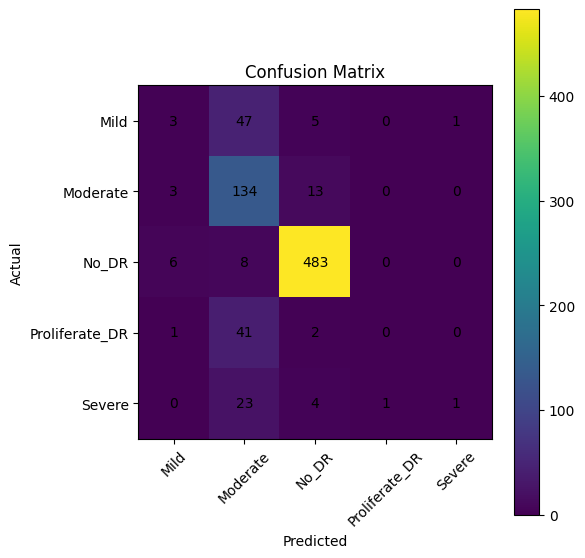

In [40]:
import numpy as np

# Predict probabilities
pred_probs = model.predict(test_batches)

# Convert to predicted class index
y_pred = np.argmax(pred_probs, axis=1)#

y_true = test_batches.classes

class_names = list(test_batches.class_indices.keys())
print(class_names)


from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)


import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Add numbers
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

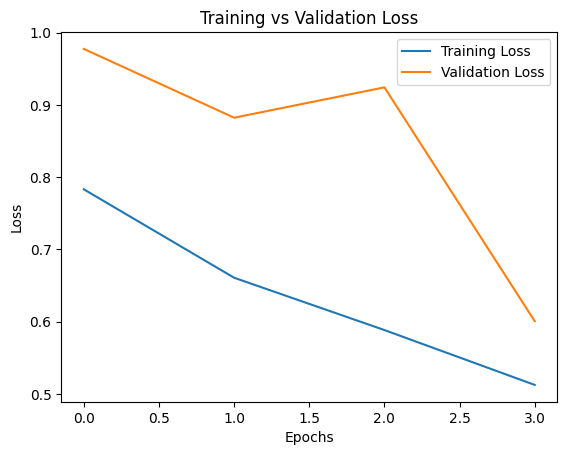

In [41]:
# Get loss values
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot
plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()